<a href="https://colab.research.google.com/github/erickdiaz3010/Economic-Complexity-Report/blob/Main-Branch-for-the-assigment/final_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings
!pip install seaborn
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)


In [6]:
#Define Mcp, connecting (imaginary) countries and activities.

countries=['Vale of Arryn','The North','The Riverlands', 'Dorne', 'The Stormland','The Westerlands','The Reach']
activities=[f'P{j}' for j in range(9)]

Mcp=np.array([[1, 0, 1, 0, 1, 1, 0, 0, 1],
            [0, 1, 1, 0, 0, 1, 1, 0, 0],
            [0, 1, 0, 1, 1, 0, 0, 0, 0],
            [1, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 1, 0, 1],
            [0, 1, 1, 0, 1, 0, 1, 1, 1],
            [1, 1, 1, 1, 1, 0, 1, 1, 1]])
R,C=Mcp.shape

**1. Descriptive Statistics**

*   Provide key statistics on the countries, including measures of economic
diversification and specialization.
*   Analyze the ubiquity of products and activities.



🔹 Descriptive Statistics
Average diversification: 4.43
Median diversification: 4.00
Standard deviation of diversification: 1.92
Average ubiquity: 3.44
Median ubiquity: 4.00
Standard deviation of ubiquity: 0.96

Countries ordered by diversification: ['The Reach', 'The Westerlands', 'Vale of Arryn', 'The North', 'The Stormland', 'The Riverlands', 'Dorne']


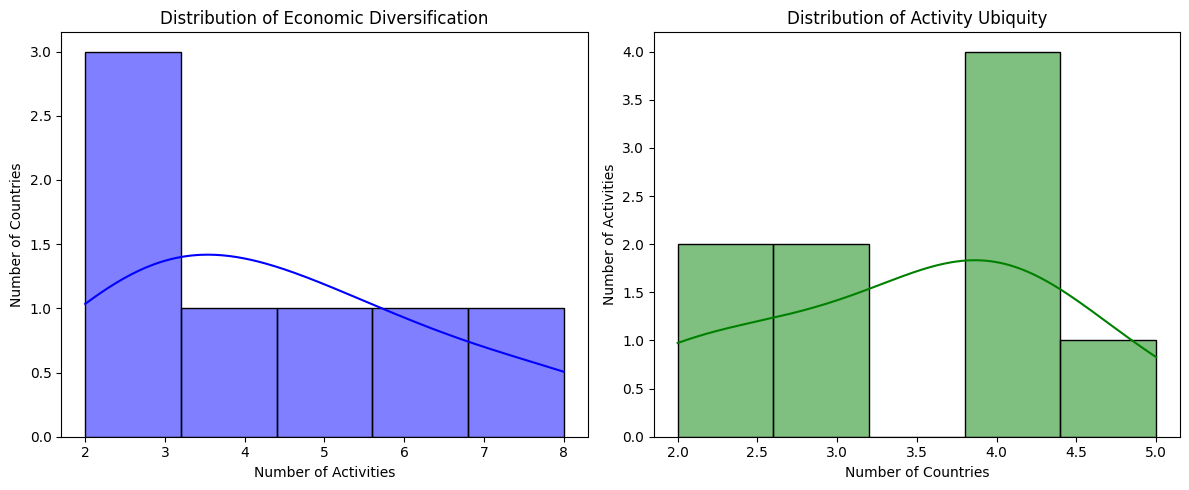

In [8]:

# Compute diversification (Number of activities per country)
diversification = Mcp.sum(axis=1)

# Compute ubiquity (Number of countries per activity)
ubiquity = Mcp.sum(axis=0)

# Order countries based on diversification
ordered_countries = np.argsort(diversification)[::-1]
sorted_countries = [countries[i] for i in ordered_countries]

# Print diversification and ubiquity statistics
print("🔹 Descriptive Statistics")
print(f"Average diversification: {np.mean(diversification):.2f}")
print(f"Median diversification: {np.median(diversification):.2f}")
print(f"Standard deviation of diversification: {np.std(diversification):.2f}")
print(f"Average ubiquity: {np.mean(ubiquity):.2f}")
print(f"Median ubiquity: {np.median(ubiquity):.2f}")
print(f"Standard deviation of ubiquity: {np.std(ubiquity):.2f}")
print("\nCountries ordered by diversification:", sorted_countries)

# Create histograms
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for diversification
sns.histplot(diversification, bins=5, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Distribution of Economic Diversification")
ax[0].set_xlabel("Number of Activities")
ax[0].set_ylabel("Number of Countries")

# Histogram for ubiquity
sns.histplot(ubiquity, bins=5, kde=True, ax=ax[1], color='green')
ax[1].set_title("Distribution of Activity Ubiquity")
ax[1].set_xlabel("Number of Countries")
ax[1].set_ylabel("Number of Activities")

plt.tight_layout()
plt.show()

Descriptive Statistics Analysis
This section examines the economic diversification and specialization of the imaginary countries by analyzing their participation in various activities. Economic diversification measures the number of activities in which a country is involved, indicating whether its economy is broad-based or specialized. Activity ubiquity, on the other hand, quantifies how many countries engage in each activity, distinguishing between common and exclusive industries. To illustrate these metrics, two histograms display the distribution of diversification among countries and the ubiquity of activities across the dataset.

The results show that, on average, countries engage in 4.43 activities, with a median of 4.00 and a standard deviation of 1.92, highlighting variations in diversification levels. Meanwhile, activities are performed by an average of 3.44 countries, with a median of 4.00 and a standard deviation of 0.96, suggesting a relatively even distribution. The higher variability in diversification indicates that some countries are more specialized, while others engage in a broad range of activities, whereas the lower variability in ubiquity suggests that most activities are moderately widespread.

These findings provide insight into the economic structures of the countries, establishing a foundation for further analysis. Understanding how diversification and ubiquity interact is crucial for assessing economic complexity, which will be explored in the next section through Economic Complexity and Fitness Measures.

**2. Economic Complexity and Fitness Measures**

*   Compute and compare the Economic Complexity Index (ECI) and Fitness for
countries.
*   Calculate the Product Complexity Index (PCI) and Activity Complexity for
activities.

*   Discuss the differences between these methodologies and how they affect country rankings.





🔹 Fitness-Complexity Results
Vale of Arryn: Fitness = 0.7841
The North: Fitness = 0.6331
The Riverlands: Fitness = 0.9733
Dorne: Fitness = 0.2092
The Stormland: Fitness = 0.5130
The Westerlands: Fitness = 1.6189
The Reach: Fitness = 2.2684
P0: Complexity = 0.4434
P1: Complexity = 0.7858
P2: Complexity = 0.3313
P3: Complexity = 1.9616
P4: Complexity = 0.8569
P5: Complexity = 0.5996
P6: Complexity = 0.6279
P7: Complexity = 2.7210
P8: Complexity = 0.6725


<ipython-input-10-68557248bcb3>:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(countries))


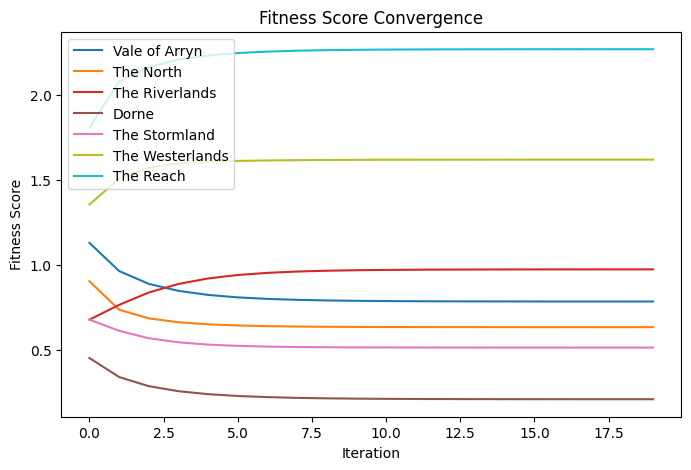

In [10]:
# Function to compute one iteration of the Fitness-Complexity Algorithm
def fitCompOneStep(Mcp, Fitness):
    R, C = Mcp.shape
    Complexity = np.zeros(C)

    for p in range(C):
        try:
            sumCT = Mcp[:, p] / Fitness
            sumCT[np.isnan(sumCT)] = 0.
            Complexity[p] = 1. / np.sum(sumCT)
            if np.isnan(Complexity[p]):
                Complexity[p] = 0
        except ZeroDivisionError:
            Complexity[p] = 0

    Fitness = np.dot(Mcp, Complexity)
    return Fitness / np.mean(Fitness), Complexity / np.mean(Complexity)

# Function to compute Fitness and Complexity over multiple iterations
def FitnessComplexity(Mcp, max_iterations=10):
    diversification = np.sum(Mcp, axis=1)
    ubiquity = np.sum(Mcp, axis=0)

    F = diversification / diversification.sum()
    Q = ubiquity / ubiquity.sum()

    for _ in range(max_iterations):
        F, Q = fitCompOneStep(Mcp, F)

    return (F / F.mean()), (Q / Q.mean())

# Compute Fitness and Complexity
fitness, complexity = FitnessComplexity(Mcp, max_iterations=20)

# Print results
print("🔹 Fitness-Complexity Results")
for i, country in enumerate(countries):
    print(f"{country}: Fitness = {fitness[i]:.4f}")

for j, activity in enumerate(activities):
    print(f"{activity}: Complexity = {complexity[j]:.4f}")

# Generate colors for each country
colors = plt.cm.get_cmap("tab10", len(countries))

# Plot Fitness convergence
iterations = 20
F_series = []

for it in range(iterations):
    F, _ = FitnessComplexity(Mcp, it)
    F_series.append(F)

F_series = np.array(F_series)

plt.figure(figsize=(8, 5))
for i, country in enumerate(countries):
    plt.plot(F_series[:, i], label=country, color=colors(i))

plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.title("Fitness Score Convergence")
plt.legend(loc="best")  # Add legend to identify countries
plt.show()